# MLFlow for Kaggle II - Loan Approval Prediction

In this notebook we will use the Loan Approval dataset to demonstrate how to build a machine learning pipeline using the MLFlow library. We will use the following steps:

1. Data Collection
2. Data Exploration
3. EDA - Exploratory Data Analysis
4. Data Preprocessing
5. Model Selection
6. Model Training
7. Model Evaluation
8. Model Optimization
9. Model Tracking
10. Kaggle Submission


## 1. Data Collection

### Loan Approval Prediction

Go to the [Loan Approval Prediction Competition](https://www.kaggle.com/competitions/playground-series-s4e10/overview). **Join the competition** and accept the terms and conditions.

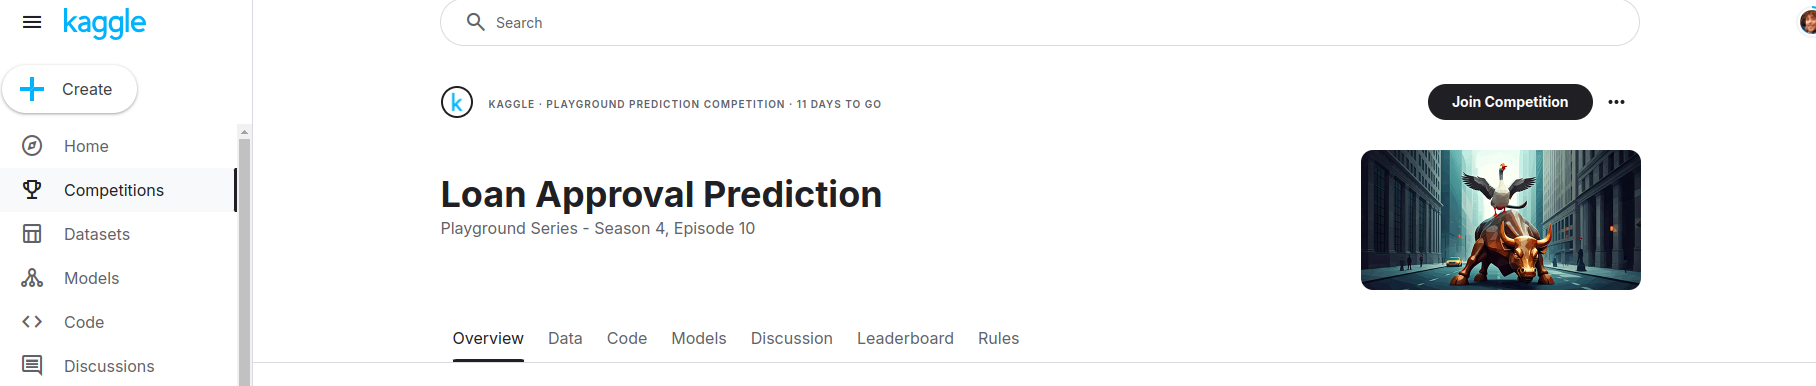

Now **download the data manually** by going to `Data` > `Download Data`

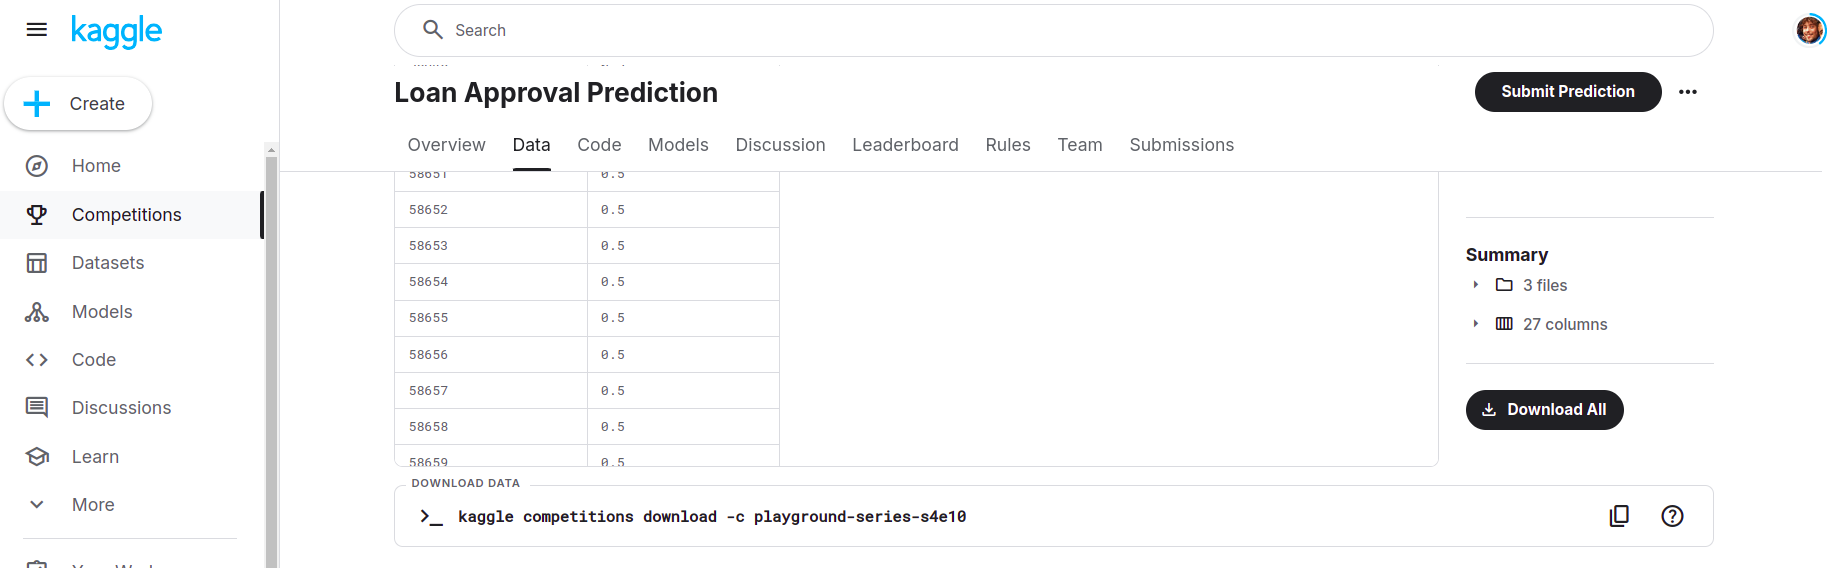

Once we've downloaded the data we are going to save it into `data/loan_prediciton`. We can see there are three files:

- `train.csv`: The training data
- `test.csv`: The test data
- `sample_submission.csv`: The sample submission file

ℹ️ Remember that `test.csv` does not have the target column, we will use it to evaluate our model against the kaggle platform.

## 2. Data Exploration

Let's load the data and take a look at the first few rows.

In [2]:
import pandas as pd


DATA_FOLDER = "../data/loan/"
TRAIN_CSV_PATH = DATA_FOLDER + "train.csv"
TEST_CSV_PATH = DATA_FOLDER + "test.csv"


train_df = pd.read_csv(TRAIN_CSV_PATH, index_col='id')
test_df = pd.read_csv(TEST_CSV_PATH, index_col='id')

train_df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status
id,,,,,,,,,,,,
0,37,35000,RENT,0.0,EDUCATION,B,6000,11.49,0.17,N,14,0
1,22,56000,OWN,6.0,MEDICAL,C,4000,13.35,0.07,N,2,0
2,29,28800,OWN,8.0,PERSONAL,A,6000,8.90,0.21,N,10,0
3,30,70000,RENT,14.0,VENTURE,B,12000,11.11,0.17,N,5,0
4,22,60000,RENT,2.0,MEDICAL,A,6000,6.92,0.10,N,3,0


**Feature Descriptions**

- person_age: Applicant’s age in years.
- person_income: Annual income of the applicant in USD.
- person_home_ownership: Status of homeownership (e.g., Rent, Own, Mortgage).
- person_emp_length: Length of employment in years.
- loan_intent: Purpose of the loan (e.g., Education, Medical, Personal).
- loan_grade: Risk grade assigned to the loan, assessing the applicant’s creditworthiness.
- loan_amnt: Total loan amount requested by the applicant.
- loan_int_rate: Interest rate associated with the loan.
- loan_percent_income: Percentage of the applicant’s income allocated towards loan repayment.
- cb_person_default_on_file: Indicates if the applicant has a history of default ('Y' for yes, 'N' for no).
- cb_person_cred_hist_length: Length of the applicant’s credit history in years.
- loan_status: The approval status of the loan (1 for rejected, 0 for approved).

In [3]:
train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
person_age,58645.0,27.550857,6.033216,20.00,23.00,26.00,30.00,123.00
person_income,58645.0,64046.172871,37931.106978,4200.00,42000.00,58000.00,75600.00,1900000.00
person_emp_length,58645.0,4.701015,3.959784,0.00,2.00,4.00,7.00,123.00
loan_amnt,58645.0,9217.556518,5563.807384,500.00,5000.00,8000.00,12000.00,35000.00
loan_int_rate,58645.0,10.677874,3.034697,5.42,7.88,10.75,12.99,23.22
loan_percent_income,58645.0,0.159238,0.091692,0.00,0.09,0.14,0.21,0.83
cb_person_cred_hist_length,58645.0,5.813556,4.029196,2.00,3.00,4.00,8.00,30.00
loan_status,58645.0,0.142382,0.349445,0.00,0.00,0.00,0.00,1.00


## 3. EDA - Exploratory Data Analysis

Let's dive into the data and understand it better. In order to do so we import the plotting libraries.

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt




We will look at the following:

- Distribution of the loan amount


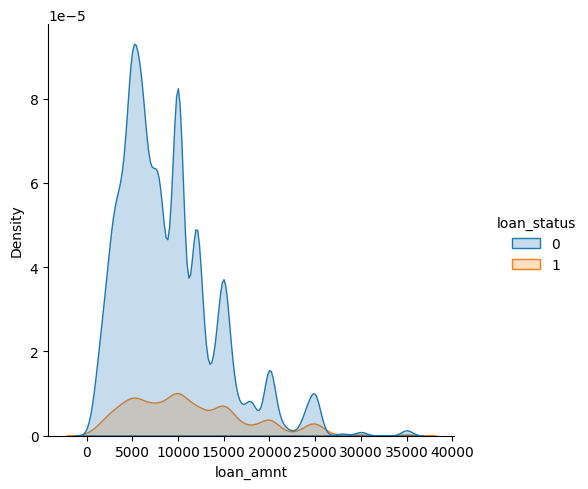

In [5]:
ax = sns.displot(train_df, x='loan_amnt', hue='loan_status', kind='kde', fill=True)

- Distribution of the applicant income

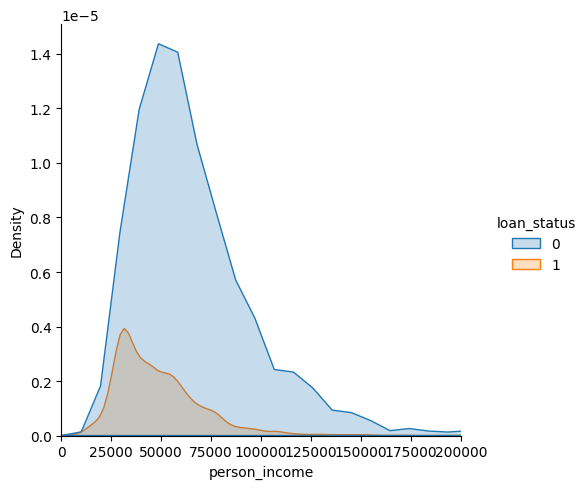

In [6]:
ax = sns.displot(train_df, x='person_income', hue='loan_status', kind='kde', fill=True)
ax.set(xlim=(0, 200000))

- person income vs loan amount

[(0.0, 200000.0)]

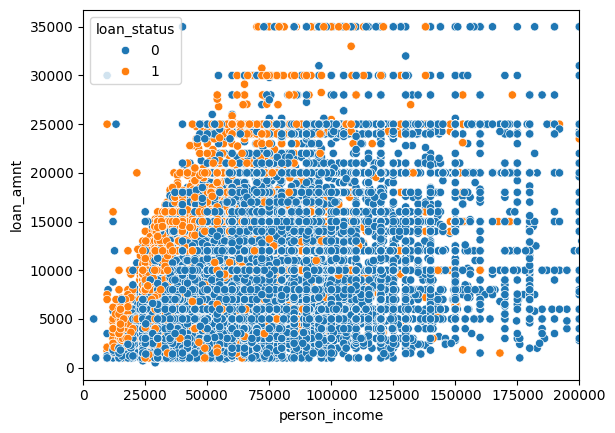

In [7]:
ax = sns.scatterplot(data=train_df, x='person_income', y='loan_amnt', hue='loan_status')
ax.set(xlim=(0, 200000))

- Loan Percent Income

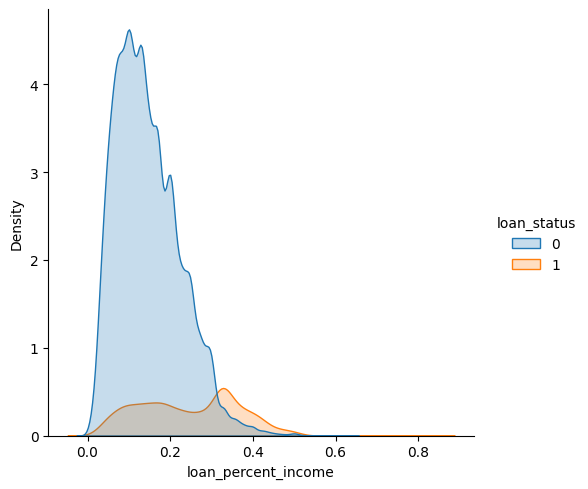

In [8]:
ax = sns.displot(train_df, x='loan_percent_income', hue='loan_status', kind='kde', fill=True)

## 4. Data Preprocessing



Aqui vemos un mapa de calor para comprobar cuales columnas son necesarias y cuales no

<Axes: >

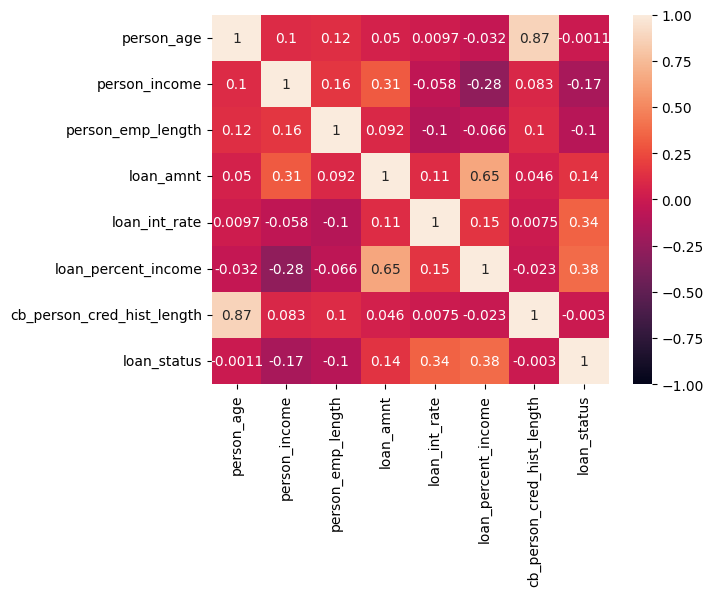

In [9]:
import numpy as np
num = train_df.select_dtypes(include=[np.number]).columns
corr = train_df[num]
sns.heatmap(corr.corr(), annot=True, vmin=-1, vmax=1)

Creamos el preprocesador para escalar las variables numericas y codificar las variables numericas

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder


num_cols = train_df.select_dtypes(include=[np.number])
cat_cols = train_df.select_dtypes(include=[object])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(), num_cols),
    ],
    remainder = 'drop',
)

## 5. Model Selection

Usamos RandomizedSearchCV 

Primero codificamos las columnas categoricas 

In [ ]:

import numpy as np
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
data_cod = train_df.copy()
for column in cat_cols.columns:
    data_cod[column+'_cod'] = le.fit_transform(np.array(train_df[column]))
    data_cod.drop(columns=column, axis=1, inplace=True)
# data_cod



A continuacion hacemos la particion de los datos para entrenamiento y validacion

In [46]:
from sklearn.model_selection import train_test_split

TEST_SIZE = 0.2
RANDOM_STATE = 42

X = data_cod.drop(columns=['loan_status'])
Y = data_cod['loan_status']

xtrain, xval, ytrain, yval = train_test_split(X, Y, test_size=TEST_SIZE, random_state=RANDOM_STATE)

En este paso usamos GradientBoostingClassifier como modelo
Usamos tambien RamdomizedSeaarchCV para probar diferentes parametros y encontrar la mejor combinacion

In [ ]:
# Gradient Boosting Classifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV

model = GradientBoostingClassifier(random_state=42)

param_grid = {
    'max_depth':[10,20,30,40,50,60,70,80,90],
    'min_samples_split': [2,4,6,8,10],
    'min_samples_leaf': [2,4,6,8,10] 
}

grid_search = RandomizedSearchCV(estimator=model, param_distributions=param_grid, cv=5)

grid_search.fit(xtrain, ytrain)

best_model = grid_search.best_estimator_

best_params = grid_search.best_params_
# best_params = {'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': 20}
print(best_params)

{'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': 20}


Representamos la curva de ROC para ver la efectividad de nuestro modelo previo a la creacion del pipeline

Text(0.5, 1.0, 'ROC Curve')

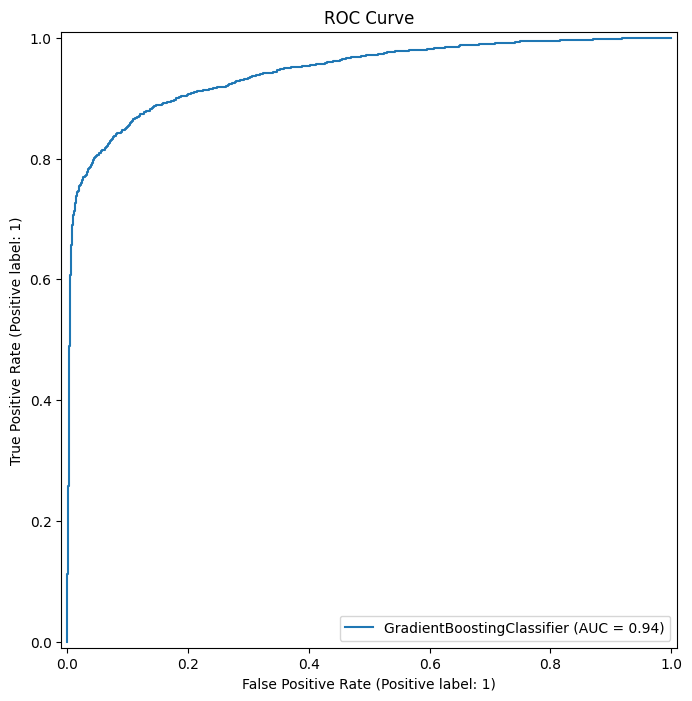

In [48]:
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(8, 8))
RocCurveDisplay.from_estimator(best_model, xval, yval, ax=ax)
ax.set_title('ROC Curve')

Comprobamos el auc score

In [49]:
from sklearn.metrics import roc_auc_score


y_pred = best_model.predict(xval)
auc_metric = roc_auc_score(yval, y_pred)

print(f'AUC: {auc_metric:.4f}')

AUC: 0.8562


Creamos un pipeline para automatizar el proceso


In [50]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('base_model', best_model),
])
pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('base_model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

## 6. Entrenamiento del modelo

Usamos los mismos splits anteriormente usados para encontrar el mejor modelo 

In [ ]:
pipeline.fit(xtrain, ytrain)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('base_model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

## 7. Evaluacion del modelo

Usamos el area de debajo de la curva de Roc para ello

In [ ]:
from sklearn.metrics import roc_auc_score


y_pred = pipeline.predict(xval)
auc_metric = roc_auc_score(yval, y_pred)

print(f'AUC: {auc_metric:.4f}')

AUC: 0.8593


Display the ROC Curve

## 8. Optimizacion del modelo

Optimizamos el modelo 

In [ ]:
y_probs = pipeline.predict_proba(xval)
y_tp_probs = y_probs[:, 1]  # 1 == bad loan

Comprobamos el ratio de falsos positivos (frp) y el ratio de verdaderos positivos (trp) para cada thresholds

In [ ]:
from sklearn.metrics import roc_curve


fpr, tpr, thresholds = roc_curve(yval, y_tp_probs)



Buscamos el punto optimo maximizando la diferencia entre los verdaderos y falsos positivos

In [57]:
import numpy as np


optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
fpr_optimal = fpr[optimal_idx]
tpr_optimal = tpr[optimal_idx]

print(f'Optimal threshold: {optimal_threshold:.4f}')
print(f'FPR: {fpr_optimal:.4f}')
print(f'TPR: {tpr_optimal:.4f}')

Optimal threshold: 0.0132
FPR: 0.0903
TPR: 0.8465


Comparamos el AUC con el threshold 0.5 como predeterminado

In [58]:
average_idx = len(thresholds) // 2
average_threshold = thresholds[average_idx]
fpr_average = fpr[average_idx]
tpr_average = tpr[average_idx]

print(f'Average threshold: {average_threshold:.4f}')
print(f'FPR: {fpr_average:.4f}')
print(f'TPR: {tpr_average:.4f}')

Average threshold: 0.0146
FPR: 0.0871
TPR: 0.8404


Una grafica del threshold predetermindado y el optimo

Text(0.08714186576781997, 0.8404384896467723, 'Average Threshold: 0.01')

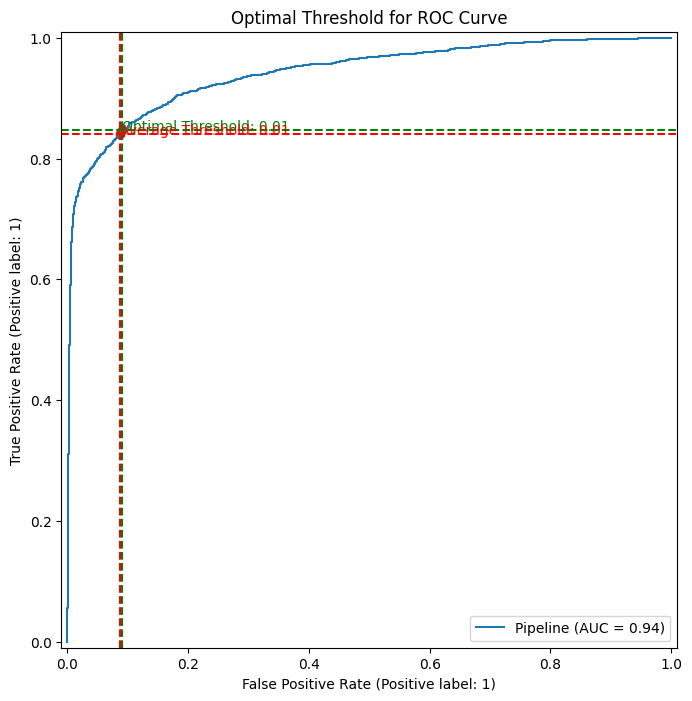

In [59]:
from sklearn.metrics import RocCurveDisplay, roc_curve, auc

fig, ax = plt.subplots(figsize=(8, 8))
RocCurveDisplay.from_estimator(pipeline, X_val, y_val, ax=ax)
ax.set_title('Optimal Threshold for ROC Curve')

# add optimal point coordinates
ax.axvline(fpr_optimal, color='g', linestyle='--')
ax.axhline(tpr_optimal, color='g', linestyle='--')
ax.scatter(fpr_optimal, tpr_optimal, color='green')  # Añadir el punto
ax.text(fpr_optimal, tpr_optimal, f'Optimal Threshold: {optimal_threshold:.2f}', color='green')

# add average point coordinates
ax.axvline(fpr_average, color='r', linestyle='--')
ax.axhline(tpr_average, color='r', linestyle='--')
ax.scatter(fpr_average, tpr_average, color='red')  # Añadir el punto
ax.text(fpr_average, tpr_average, f'Average Threshold: {average_threshold:.2f}', color='red')

Añadimos un "tuneo" a nuestro pipeline

In [60]:
from sklearn.model_selection import TunedThresholdClassifierCV


model = TunedThresholdClassifierCV(pipeline, scoring="roc_auc")

Entrenamos el modelo con el nuevo pipeline 

In [ ]:
model.fit(xtrain, ytrain)

,"estimator estimator: estimator instanceThe classifier, fitted or not, for which we want to optimizethe decision threshold used during `predict`.",Pipeline(step...m_state=42))])
,"scoring scoring: str or callable, default=""balanced_accuracy""The objective metric to be optimized. Can be one of:- str: string associated to a scoring function for binary classification, see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)``. See :ref:`scoring_callable` for details.",'roc_auc'
,"response_method response_method: {""auto"", ""decision_function"", ""predict_proba""}, default=""auto""Methods by the classifier `estimator` corresponding to thedecision function for which we want to find a threshold. It can be:* if `""auto""`, it will try to invoke, for each classifier, `""predict_proba""` or `""decision_function""` in that order.* otherwise, one of `""predict_proba""` or `""decision_function""`. If the method is not implemented by the classifier, it will raise an error.",'auto'
,"thresholds thresholds: int or array-like, default=100The number of decision threshold to use when discretizing the output of theclassifier `method`. Pass an array-like to manually specify the thresholdsto use.",100
,"cv cv: int, float, cross-validation generator, iterable or ""prefit"", default=NoneDetermines the cross-validation splitting strategy to train classifier.Possible inputs for cv are:* `None`, to use the default 5-fold stratified K-fold cross validation;* An integer number, to specify the number of folds in a stratified k-fold;* A float number, to specify a single shuffle split. The floating number should be in (0, 1) and represent the size of the validation set;* An object to be used as a cross-validation generator;* An iterable yielding train, test splits;* `""prefit""`, to bypass the cross-validation.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... warning:: Using `cv=""prefit""` and passing the same dataset for fitting `estimator` and tuning the cut-off point is subject to undesired overfitting. You can refer to :ref:`TunedThresholdClassifierCV_no_cv` for an example. This option should only be used when the set used to fit `estimator` is different from the one used to tune the cut-off point (by calling :meth:`TunedThresholdClassifierCV.fit`).",None
,"refit refit: bool, default=TrueWhether or not to refit the classifier on the entire training set oncethe decision threshold has been found.Note that forcing `refit=False` on cross-validation having morethan a single split will raise an error. Similarly, `refit=True` inconjunction with `cv=""prefit""` will raise an error.",True
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. When `cv` represents across-validation strategy, the fitting and scoring on each data splitis done in parallel. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of cross-validation when `cv` is a float.See :term:`Glossary `.",None
,"store_cv_results store_cv_results: bool, default=FalseWhether to store all scores and thresholds computed during the cross-validationprocess.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-

Evaluamos el modelo

In [62]:
from sklearn.metrics import roc_auc_score


y_pred = model.predict(X_val)
auc_metric = roc_auc_score(y_val, y_pred)

print(f'AUC: {auc_metric:.4f}')

AUC: 0.8751


In [63]:
import numpy as np
from sklearn.metrics import roc_curve


y_tp_probs = model.predict_proba(X_val)[:, 1]
fpr, tpr, thresholds = roc_curve(y_val, y_tp_probs)
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = model.best_threshold_
fpr_optimal = fpr[optimal_idx]
tpr_optimal = tpr[optimal_idx]

print(f'Optimal threshold: {optimal_threshold:.4f}')
print(f'FPR: {fpr_optimal:.4f}')
print(f'TPR: {tpr_optimal:.4f}')

Optimal threshold: 0.0202
FPR: 0.0903
TPR: 0.8465


Nuevamente graficamos el threshols predeterminado y el optimo

Text(0.08714186576781997, 0.8404384896467723, 'Average Threshold: 0.01')

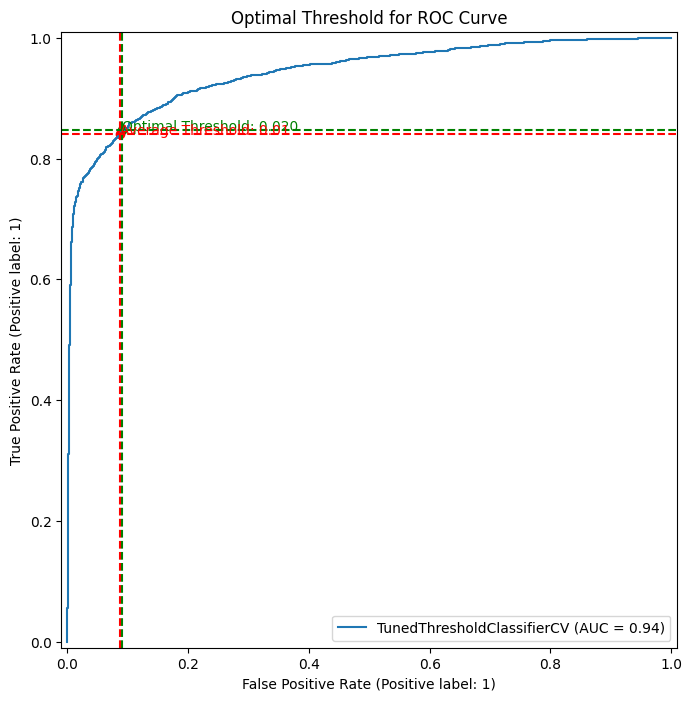

In [64]:
# Display the ROC Curve
fig, ax = plt.subplots(figsize=(8, 8))
RocCurveDisplay.from_estimator(model, X_val, y_val, ax=ax)
ax.set_title('Optimal Threshold for ROC Curve')


# add optimal point coordinates
ax.axvline(fpr_optimal, color='g', linestyle='--')
ax.axhline(tpr_optimal, color='g', linestyle='--')
ax.scatter(fpr_optimal, tpr_optimal, color='green')  # Añadir el punto
ax.text(fpr_optimal, tpr_optimal, f'Optimal Threshold: {optimal_threshold:.3f}', color='green')

# add average point coordinates
ax.axvline(fpr_average, color='r', linestyle='--')
ax.axhline(tpr_average, color='r', linestyle='--')
ax.scatter(fpr_average, tpr_average, color='red')  # Añadir el punto
ax.text(fpr_average, tpr_average, f'Average Threshold: {average_threshold:.2f}', color='red')

### Generate submission file

Looking at the `submission_sample.csv` file we see that it hmut have two columns: `id` and `loan_status`. The `id` column must have the same values as the test set and the `loan_status` column must have the predictions.

In [65]:
# Save the CSV to be submitted to a file
SUBMISSION_CSV_PATH = DATA_FOLDER + 'submission.csv'

# obtain the predictions
y_test_pred = model.predict(test_df)


# prepare the data to be submitted
ids_column = test_df.index
submission_data = {
    "id": ids_column,
    "loan_status": y_test_pred
}

# save it to a CSV file
submission_df = pd.DataFrame(submission_data)
submission_df.to_csv(SUBMISSION_CSV_PATH, index=False)
submission_df.head()

,id,loan_status
0,58645,1
1,58646,0
2,58647,1
3,58648,0
4,58649,0


## 9. Model Tracking

Once we have trained the model we can use the MLFlow library to track the model performance. We can log the AUC, the metrics, the submission file...

### Connect to MLFlow

In [66]:
import mlflow


mlflow.set_tracking_uri("http://localhost:5000")
mlflow.set_experiment("loan_prediction")

<Experiment: artifact_location='mlflow-artifacts:/2', creation_time=1771607281167, experiment_id='2', last_update_time=1771607281167, lifecycle_stage='active', name='loan_prediction', tags={'mlflow.experimentKind': 'custom_model_development'}>

### Submit to MLFlow

In [68]:
best_params


{'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': 20}

In [70]:
with mlflow.start_run():

    mlflow.set_tag("model", model.__class__.__name__)

    mlflow.log_metric("auc", auc_metric)
    mlflow.log_metric("optimal_threshold", optimal_threshold)
    mlflow.log_metric("fpr_optimal", fpr_optimal)
    mlflow.log_metric("tpr_optimal", tpr_optimal)
    mlflow.log_metric("average_threshold", average_threshold)
    mlflow.log_metric("fpr_average", fpr_average)
    mlflow.log_metric("tpr_average", tpr_average)
    mlflow.log_metric("min_samples_split", best_params['min_samples_split'])
    mlflow.log_metric("min_samples_leaf", best_params['min_samples_leaf'])
    mlflow.log_metric("max_depth", best_params['max_depth'])


    mlflow.sklearn.log_model(model, "model")

    mlflow.log_artifact(SUBMISSION_CSV_PATH)

2026/02/24 18:22:03 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
/workspaces/Python-intro-Data-Science/.venv/lib/python3.12/site-packages/mlflow/models/model.py:1209: FutureWarning: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is the 'skops' format.
  flavor.save_model(path=local_path, mlflow_model=mlflow_model, **kwargs)


🏃 View run tasteful-calf-772 at: http://localhost:5000/#/experiments/2/runs/542719e740e64661aa03504f69fd06a9
🧪 View experiment at: http://localhost:5000/#/experiments/2


## 10. Kaggle Submission


Finally we can submit the predictions to the kaggle platfrom. To do so we are going to retrieve the submission CSV from the best MLFlow run and submit it to the kaggle platform. You could upload the results manually by going to the kaggle website and clicking on `Submit Predictions`. You can then upload the file and submit it. Or you can use the kaggle API to submit the file:

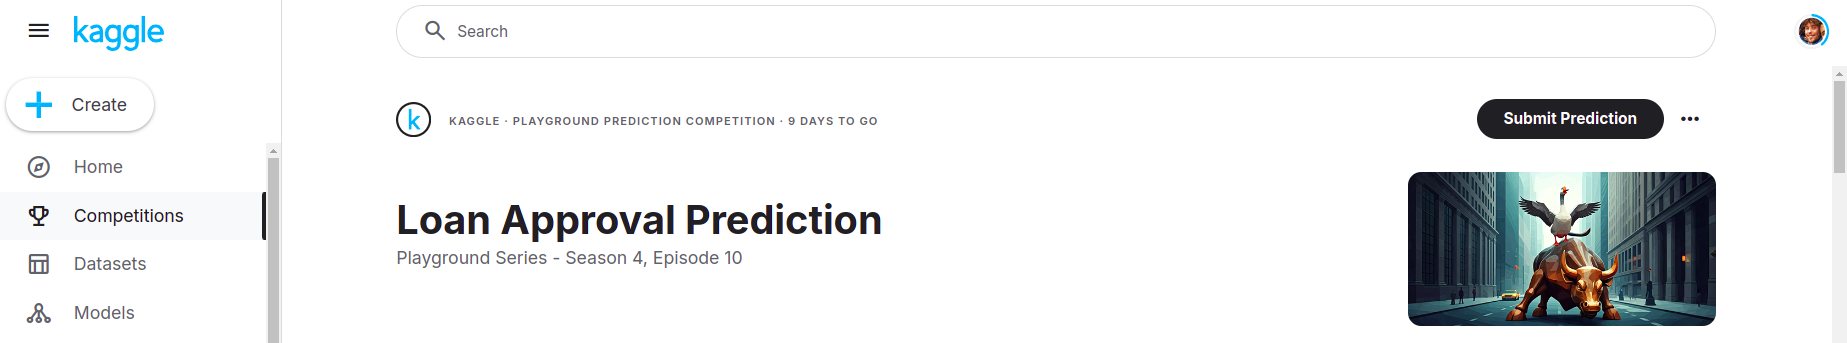

### 🎉 My Submission!:

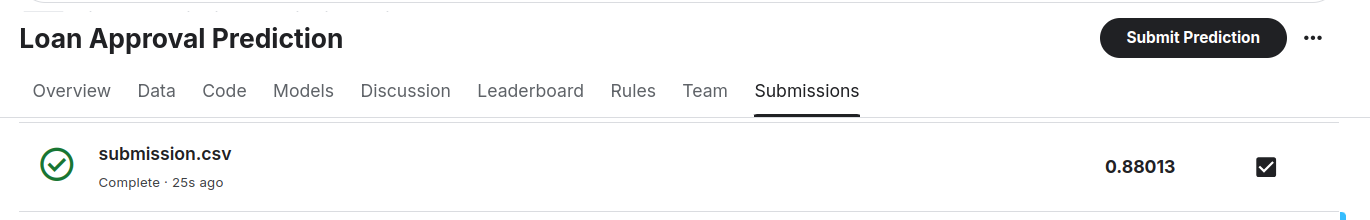